<br><h1 style='text-align: center; font-size: 2.5rem'><strong>Data Manipulation I Natural Language Processing</strong></h1>
<div style='max-width: 50%; margin: 0 auto;'>
I dette modul vil vi fokusere på data manipulation i natural language processing (NLP), da det kræver nogle lidt andre kompetencer end normal data behandling. Igennem de følgende opgaver kommer i til at få en smag på de følgende metoder/kompetencer:
<br><br>
<ul style='display: table; margin: 0 auto;'>
    <li><strong>Tekst Normalisering</strong></li>
    <li><strong>Regular Expressions</strong></li>
    <li><strong>Stopord fjerning & Stemming</strong></li>
    <li><strong>Bag Of Words (BOW) modellen</strong></li>
    <li><strong>Term Frequency, Inverse Document Frequency (TFIDF) modellen</strong></li>
</ul>
<br>
Det fede ved disse metoder ligger ikke i den smukke matematiske arkitektur og historie bag dem ligesom i tilfældet af transformeren som I vil se senere i NLP forløbet. I stedet er disse metoder fede idet de bruges overalt i praksis fra forskningsmiljøet, til virksomhedsdriften, til applikationen som bruges en million gange om dagen.
</div><br>

In [1]:
!pip install -q kagglehub && pip install -U nltk && python -c "import nltk; nltk.download('stopwords'); nltk.download('punkt'); nltk.download('punkt_tab')"

from IPython.display import clear_output
clear_output(wait=True)

print('NLTK setup complete!')

NLTK setup complete!


In [2]:
!wget -q -nc https://raw.githubusercontent.com/UNF-Science-Camps/KIC26/main/NLP/hjaelpefunktioner.py

clear_output(wait=True)
print('Helper-function setup complete!')

Helper-function setup complete!


In [3]:
import kagglehub
import numpy as np
import pandas as pd; pd.set_option('display.max_rows', 6); pd.set_option('display.max_columns', 100)
import matplotlib.pyplot as plt; plt.style.use('ggplot')
from sklearn.model_selection import train_test_split

from hjaelpefunktioner import center_show, plot_test_plot

# pakker for rengøring
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# pakker for en pæn notebook
from IPython.display import display, clear_output, HTML

clear_output()
print('Imports set up!')

Imports set up!


<div style='max-width: 50%; margin: 0 auto;'>
<h2 style='text-align: center;'><strong>1 – Dataen og Indlæsning</strong></h2>
Vi starter med at indlæse vores tekst data så vi kan rengøre den. Datasættet vi bruger for denne notebook var del af en Kaggle konkurrence som brugte tweets til at forudse om der skete ulykker.

Specielt minder dette datasæt meget om noget man ville lave hvis man selv var en data scientist for en virksomhed, da store virksomheder kunne finde på at scrape en masse tweets og så sortere dem ind i grupperne; [<strong>dårlig omtale</strong>, <strong>god omtale</strong>, <strong>ingen omtale</strong>] for at få et overblik om hvordan offentligheden opfatter dem.
</div>


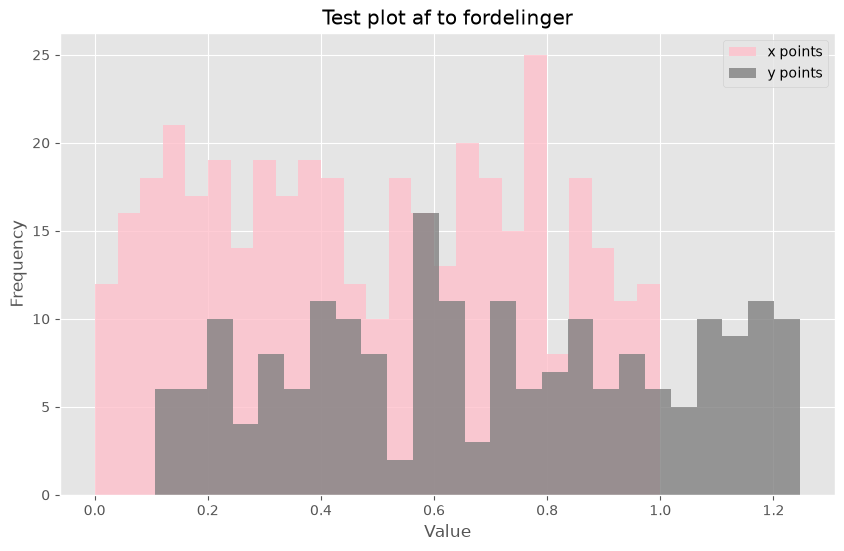

In [4]:
# eksempel plot
xpts = np.random.random(400)
ypts = 1.15*np.random.random(200) + 0.1

plt.figure(figsize=(10,6))
plt.hist(xpts, bins=25, color='pink', alpha=0.8, label='x points')
plt.hist(ypts, bins=25, color='grey', alpha=0.8, label='y points')
plt.xlabel('Value'); plt.ylabel('Frequency')
plt.legend()
plt.title('Test plot af to fordelinger')
plot_test_plot()

In [5]:
tweets = kagglehub.competition_download('nlp-getting-started')
print(tweets + '\n')

train = pd.read_csv(f'{tweets}/train.csv', usecols=['id','text','target'], index_col='id')
test = pd.read_csv(f'{tweets}/test.csv', usecols=['id','text'], index_col='id')

print(f'train set: {train.shape}')
print(f'test set: {test.shape}')

/Users/daniel/.cache/kagglehub/competitions/nlp-getting-started

train set: (7613, 2)
test set: (3263, 1)


In [6]:
print('train set:')
display(train.head())

print('\ntest set:')
display(test.head())

train set:


,text,target
id,,
1,Our Deeds are the Reason of this #earthquake M...,1
4,Forest fire near La Ronge Sask. Canada,1
5,All residents asked to 'shelter in place' are ...,1
6,"13,000 people receive #wildfires evacuation or...",1
7,Just got sent this photo from Ruby #Alaska as ...,1



test set:


,text
id,
0,Just happened a terrible car crash
2,"Heard about #earthquake is different cities, s..."
3,"there is a forest fire at spot pond, geese are..."
9,Apocalypse lighting. #Spokane #wildfires
11,Typhoon Soudelor kills 28 in China and Taiwan


<h3 style='text-align: center;'><strong>Tekst Normalisering</strong></h3>
<div style='max-width: 50%; margin: 0 auto;'>
generelt er web-scraped tekst meget støjet og kaotisk, hvilket gør det svært for ens model at lære meget fra det. pointen med tekst-normalisering er da at tage den støjede tekst og omdanne den til den samme "normale" form.<br><br>
eksempelvis vil vi gerne transformere disse <i><strong>grimme</strong></i> sætninger<br><br>
<div style='max-width: 80%; margin: 0 auto; color: red;'>
<strong>"The QUICK brown FOX jUmPS oVER thE lazy DoG!"</strong><br><br>
<strong>"the    ::::      quick brown\t\n fox jumps\t\t\t\t over the,;(@)&*@#$(&*) lazy dog.......\n\n\n"</strong><br><br>
<strong>"那只敏捷的棕色狐狸跳过了那只懒惰的狗。😎"</strong><br><br>
</div>
til disse <i><strong>pæne</strong></i> sætninger<br><br>
<div style='max-width: 80%; margin: 0 auto; color: green;'>
<strong>"the quick brown fox jumps over the lazy dog"</strong><br><br>
<strong>"the quick brown fox jumps over the lazy dog"</strong><br><br>
<strong>"😎"</strong><br><br>
</div>
i kode-cellen nedenfor vil vi starte vores <i>clean_text()</i> funktion ved at <i>1.</i> fjerne grammatiske symboler, <i>2.</i> fjerne lange mellemrum, tabs, og linjestykker, og <i>3.</i> konvertere bogstaver til små alpha-numeriske karakterer (a b c ... x y z 1 2 3 ... 8 9 0).
</div>

In [7]:
# tekst eksempler ovenfor
examples = [
    'The QUICK brown FOX jUmPS oVER thE lazy DoG!',
    'the    ::::      quick brown\t\n fox jumps\t\t\t\t over the,;(@)&*@#$(&*) lazy dog.......\n\n\n',
    '那只敏捷的棕色狐狸跳过了那只懒惰的狗。😎'
]

for i,ex in enumerate(examples):
    print(f'example {i+1}:')
    print(f'"{ex}"\n')

example 1:
"The QUICK brown FOX jUmPS oVER thE lazy DoG!"

example 2:
"the    ::::      quick brown	
 fox jumps				 over the,;(@)&*@#$(&*) lazy dog.......


"

example 3:
"那只敏捷的棕色狐狸跳过了那只懒惰的狗。😎"



In [12]:
def clean_text(text):

    # 1. fjern gramattiske symboler
    symbols = '`~!@#$%^&*()-+[]{}"\'\\/.,><:;\n\t'

    for s in symbols:
        text = text.replace(s, '')

    # 2. fjern store mellemrum
    old_text = None
    while text != old_text:
        old_text = text
        text = text.replace('  ', ' ')

    # 3. konverter til alpha-numerisk
    text = text.lower()
    text = ' '.join([word for word in text.split() if word.isalnum() and len(word) > 0])

    return text

cleaned_examples = [clean_text(ex) for ex in examples]

for i, ex in enumerate(cleaned_examples):
    print(f'example {i+1}:')
    print(f'"{ex}"\n')

example 1:
"the quick brown fox jumps over the lazy dog"

example 2:
"the quick brown fox jumps over the lazy dog"

example 3:
""



<h3 style='text-align: center;'><strong>Nødvendighed af REGEX</strong></h3>
<div style='max-width: 50%; margin: 0 auto;'>
Dette er godt, men vi ser et par problemer som opstår. Først og fremmest er denne rengøringsalgoritme ret langsom, hvilket kan være problematisk hvis du skal rengøre en milliard eksempler. Dernæst ser vi at nogle eksempler bliver helt ubrugelige, da de bliver helt "opryddet". Dette er godt nogle gange, da disse eksempler ellers ville korrupte vores model, men at rengøre dem kommer i kost af forståelse da de nu ingen info har længere.<br><br>
Dette eksempel understrejer nyttigheden af <i><strong>Regular Expressions</strong></i> (REGEX), idet de kan bruges til at hurtigere rydde op i grimme mønstre, og samtidig kan bruges til at spotte mønstre som ikke er rene, men som stadig har semantisk værdi og som vi derfor gerne vil beholde.
</div><br>